# Data Exploration and Cleaning

In [ ]:
# General data analysis and visualisation
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats as stats

# Variable transformation
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE, SelectFromModel
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Serialisation
import pickle

import warnings
warnings.filterwarnings('ignore')

In [84]:
# Problem 1
#demonstrate depth in 
# data exploration and cleaing
# featre engineering
# model selection and justification
# evaluation, interpretation and reasoning

# Problem 2
# High level architecture
# deployment considerations
# monitoring and model lifecycle management

# Problem 1

In [85]:
data = pd.read_csv('exercise_bank_marketing_data.csv',sep=';')
data.drop(columns=['Unnamed: 0'],inplace=True)

In [86]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,post_campaign_action
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,0
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,0


In [87]:
data.shape

(4566, 18)

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4566 entries, 0 to 4565
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   4566 non-null   int64  
 1   job                   4477 non-null   object 
 2   marital               4566 non-null   object 
 3   education             4429 non-null   object 
 4   default               4566 non-null   object 
 5   balance               4431 non-null   float64
 6   housing               4566 non-null   object 
 7   loan                  4566 non-null   object 
 8   contact               4433 non-null   object 
 9   day                   4566 non-null   int64  
 10  month                 4566 non-null   object 
 11  duration              4566 non-null   int64  
 12  campaign              4566 non-null   int64  
 13  pdays                 4566 non-null   int64  
 14  previous              4566 non-null   int64  
 15  poutcome             

In [89]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous,post_campaign_action
count,4566.000000,4431.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000
mean,41.216163,1432.096367,15.899255,263.977442,2.795226,39.882173,0.548401,0.383268
std,10.818847,3043.341454,8.254385,259.937859,3.107618,100.148744,1.709890,0.486236
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,67.000000,9.000000,104.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,445.000000,16.000000,185.000000,2.000000,-1.000000,0.000000,0.000000
75%,49.000000,1486.000000,21.000000,329.750000,3.000000,-1.000000,0.000000,1.000000
max,131.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000,1.000000


In [90]:
# Max age of 131 looks like an outlier/data entry error
# Could use Tukey IQR method, but simple approach might be better by just capping age values at a 100

In [91]:
# Keep only rows where age is logically sound
data = data[data['age'] <= 100]

In [92]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# Output the results
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'target']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'post_campaign_action']


In [93]:
missing_percent = (data.isnull().mean() * 100).sort_values(ascending=False)

# 3. Optional: Filter out columns that have 0% missing data for a cleaner view
missing_percent = missing_percent[missing_percent > 0]

print("Percentage of Missing Values per Column:\n")
print(missing_percent)

Percentage of Missing Values per Column:

education    3.003069
balance      2.959228
contact      2.915388
job          1.950899
dtype: float64


Plotting Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'target']


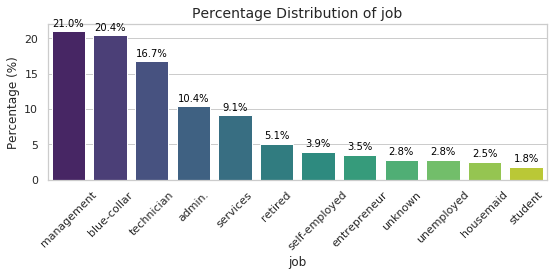

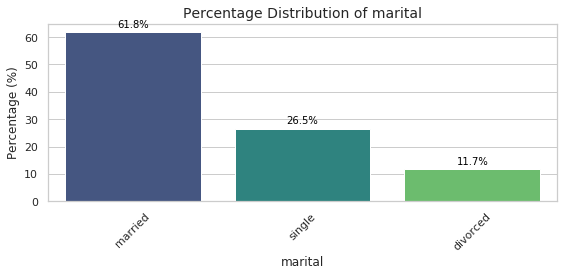

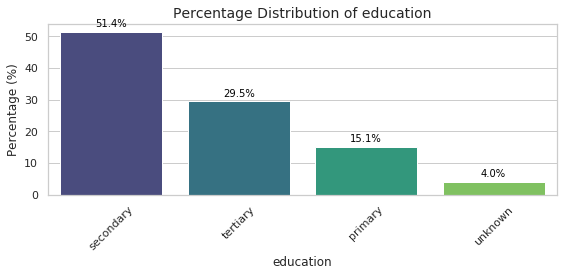

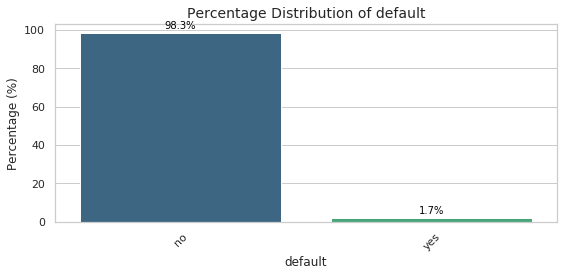

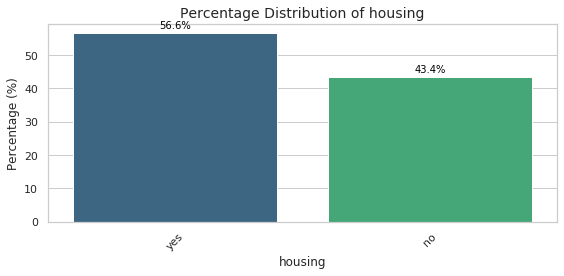

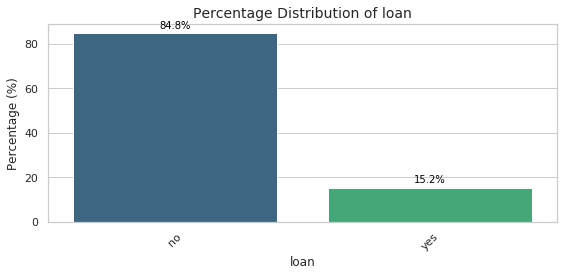

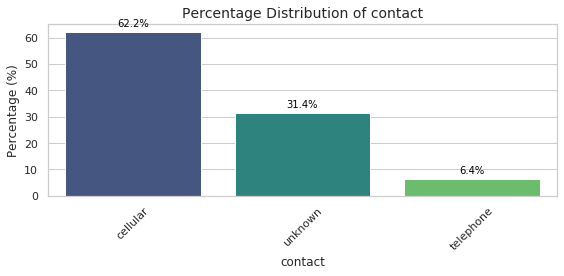

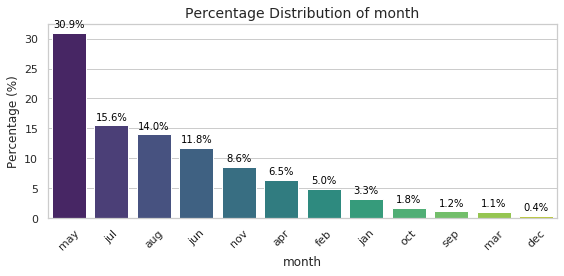

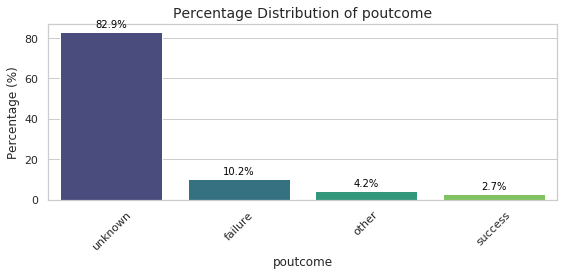

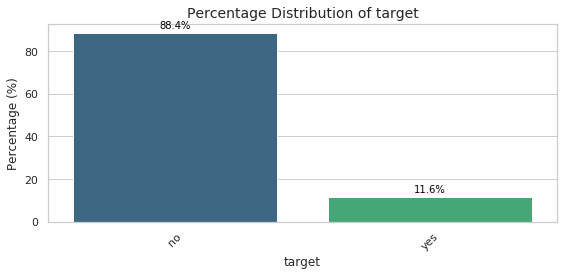

In [94]:
print(f"Plotting Categorical Columns: {categorical_cols}")

sns.set_theme(style="whitegrid")

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    
    # Calculate percentage distribution
    
    perc_dist = data[col].value_counts(normalize=True) * 100
    
    
    ax = sns.barplot(x=perc_dist.index, y=perc_dist.values, palette="viridis")
    
    plt.title(f'Percentage Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45)
    
   
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 3),
                    textcoords='offset points')
                    
    plt.tight_layout()
    plt.show()

Plotting Numeric Columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'post_campaign_action']


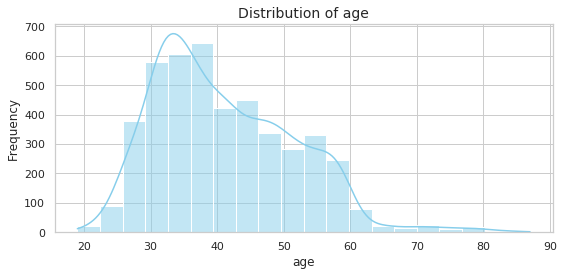

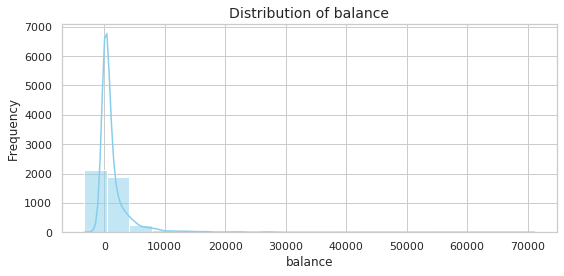

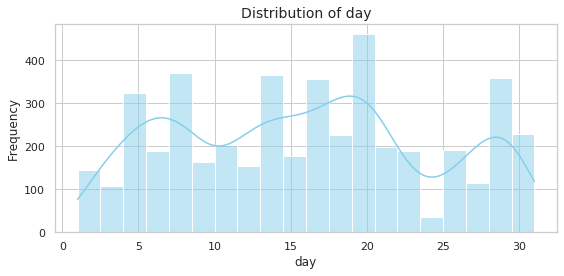

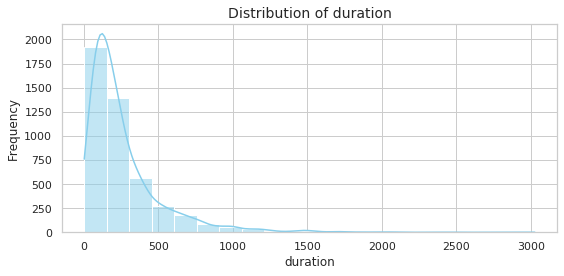

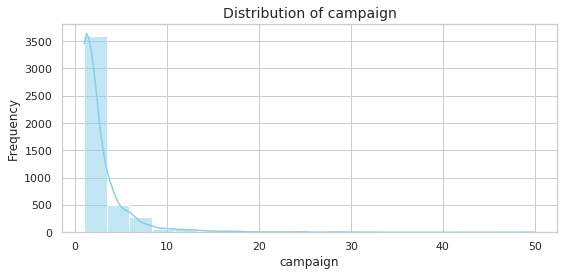

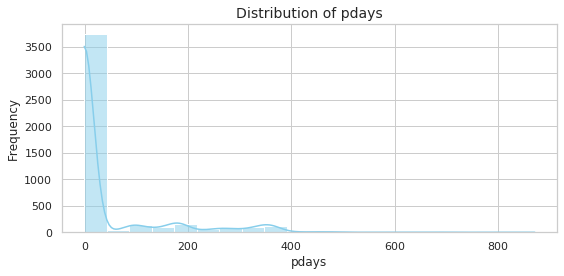

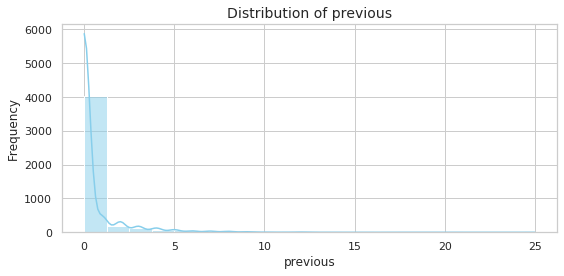

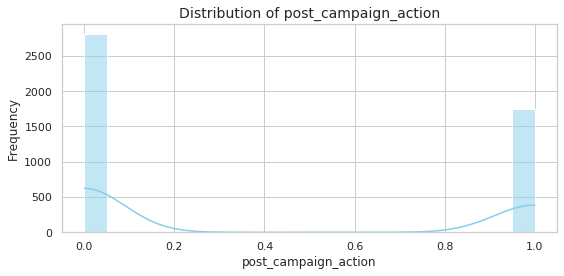

In [95]:
print(f"Plotting Numeric Columns: {numeric_cols}")

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
   
    sns.histplot(data=data, x=col, kde=True, bins=20, color='skyblue')
    
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()

In [96]:
# Impute missing values
# 1. Numeric: Fill missing 'balance' with the median
data['balance'] = data['balance'].fillna(data['balance'].median())

# 2. Categorical: Fill 'education' and 'job' with the mode (most common value)
data['education'] = data['education'].fillna(data['education'].mode()[0])
data['job'] = data['job'].fillna(data['job'].mode()[0])

# 3. Categorical (Logical): Fill 'contact' with 'Unknown'
data['contact'] = data['contact'].fillna('Unknown')

# Verify that all missing values have been handled
print(data[['education', 'balance', 'contact', 'job']].isnull().sum())

education    0
balance      0
contact      0
job          0
dtype: int64


# examine relationship between features and target

In [97]:
#convert target to numeric binary
data['target'] = data['target'].map({'yes': 1, 'no': 0})

#### Crames V interpretation
- < 0.10: Negligible / Weak association
- 0.10 - 0.20: Weak association
- 0.20 - 0.40: Moderate association
- 0.40 - 0.60: Relatively strong association
- 0.60 - 0.80: Strong association
- 0.80 - 1.00: Very strong association 

CATEGORICAL FEATURES VS TARGET

--- Analyzing: job ---


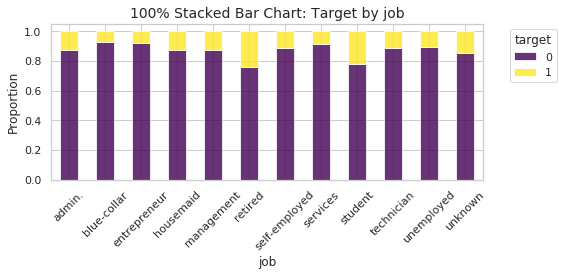

Cramér's V for job: 0.114
----------------------------------------

--- Analyzing: marital ---


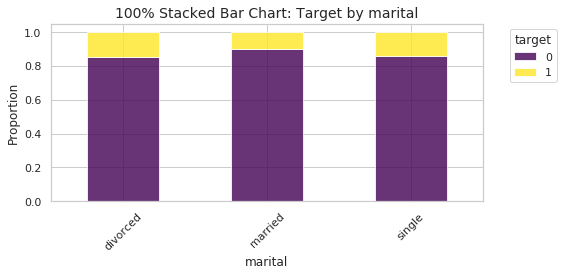

Cramér's V for marital: 0.064
----------------------------------------

--- Analyzing: education ---


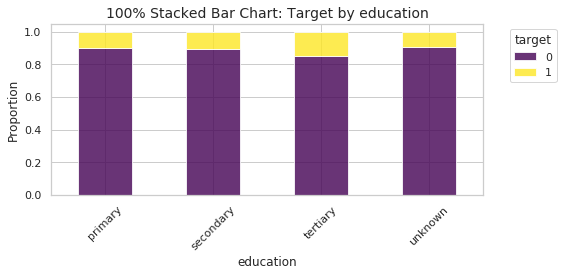

Cramér's V for education: 0.055
----------------------------------------

--- Analyzing: default ---


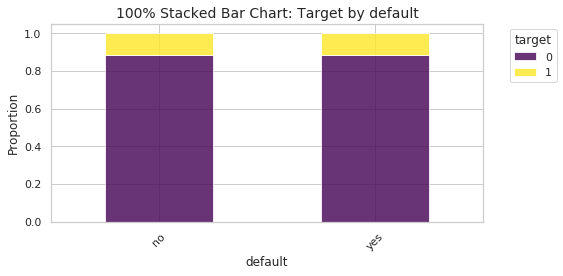

Cramér's V for default: 0.000
----------------------------------------

--- Analyzing: housing ---


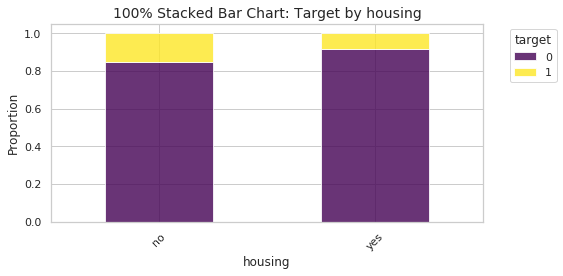

Cramér's V for housing: 0.104
----------------------------------------

--- Analyzing: loan ---


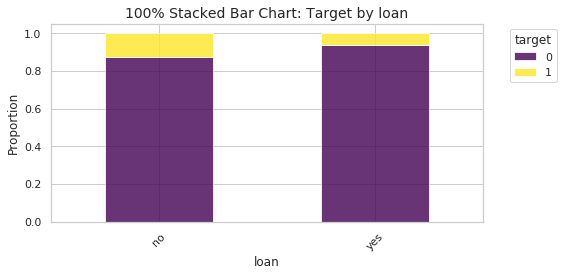

Cramér's V for loan: 0.069
----------------------------------------

--- Analyzing: contact ---


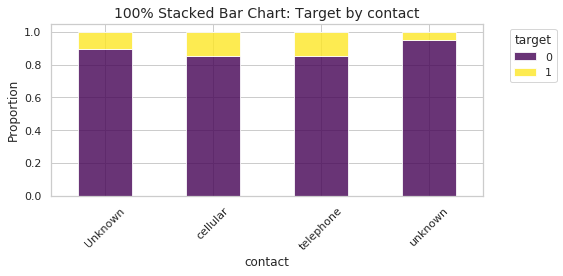

Cramér's V for contact: 0.136
----------------------------------------

--- Analyzing: month ---


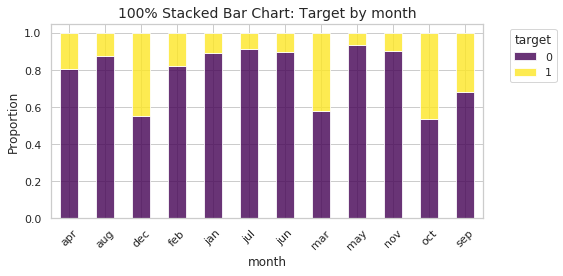

Cramér's V for month: 0.229
----------------------------------------

--- Analyzing: poutcome ---


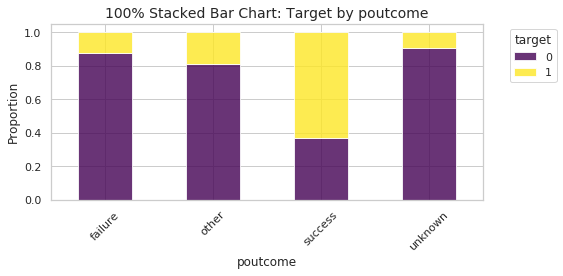

Cramér's V for poutcome: 0.274
----------------------------------------



In [99]:
def cramers_v(x, y):
    """Calculates bias-corrected Cramér's V statistic."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Set the target column name
target_col = 'target'

features_df = data.drop(columns=[target_col])
categorical_cols = features_df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = features_df.select_dtypes(include=['number']).columns.tolist()

sns.set_theme(style="whitegrid")

# ==========================================
# 1. Loop Categorical Features vs Target
# ==========================================
print("=========================================")
print("CATEGORICAL FEATURES VS TARGET")
print("=========================================\n")

for col in categorical_cols:
    print(f"--- Analyzing: {col} ---")
    
    # Plotting
    plt.figure(figsize=(8, 4))
    crosstab_prop = pd.crosstab(data[col], data[target_col], normalize='index')
    
    # ax=plt.gca() ensures pandas plots onto the current matplotlib figure
    crosstab_prop.plot(kind='bar', stacked=True, colormap='viridis', alpha=0.8, ax=plt.gca())
    
    plt.title(f"100% Stacked Bar Chart: Target by {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Proportion", fontsize=12)
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Statistics
    v_stat = cramers_v(data[col], data[target_col])
    print(f"Cramér's V for {col}: {v_stat:.3f}")
    print("-" * 40 + "\n")

NUMERIC FEATURES VS TARGET

--- Analyzing: age ---


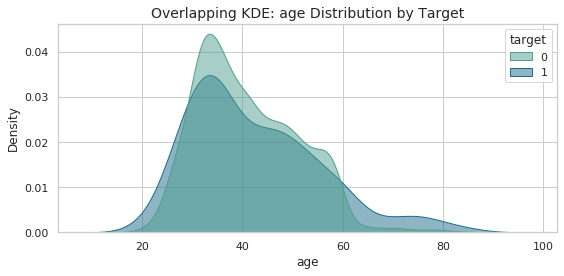

Point-Biserial Correlation: 0.044
P-value: 2.781e-03
Conclusion: The relationship is statistically significant.
----------------------------------------

--- Analyzing: balance ---


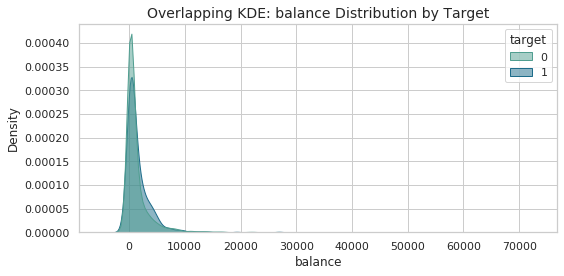

Point-Biserial Correlation: 0.017
P-value: 2.585e-01
Conclusion: The relationship is NOT statistically significant.
----------------------------------------

--- Analyzing: day ---


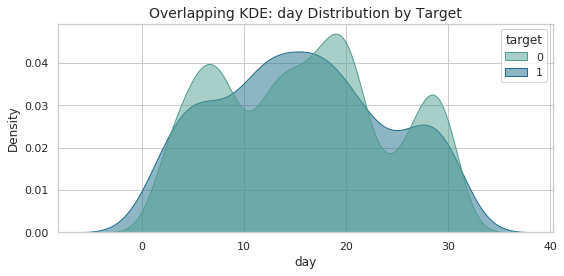

Point-Biserial Correlation: -0.011
P-value: 4.477e-01
Conclusion: The relationship is NOT statistically significant.
----------------------------------------

--- Analyzing: duration ---


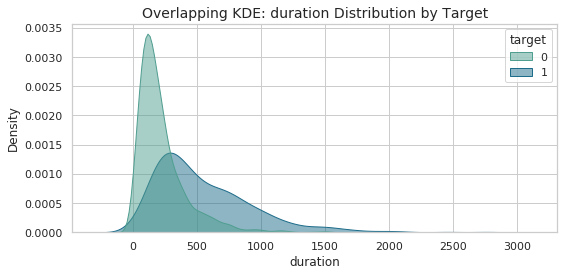

Point-Biserial Correlation: 0.402
P-value: 1.205e-176
Conclusion: The relationship is statistically significant.
----------------------------------------

--- Analyzing: campaign ---


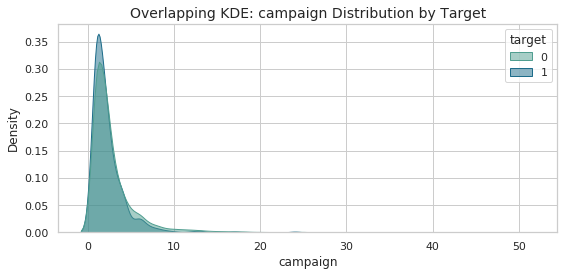

Point-Biserial Correlation: -0.062
P-value: 2.750e-05
Conclusion: The relationship is statistically significant.
----------------------------------------

--- Analyzing: pdays ---


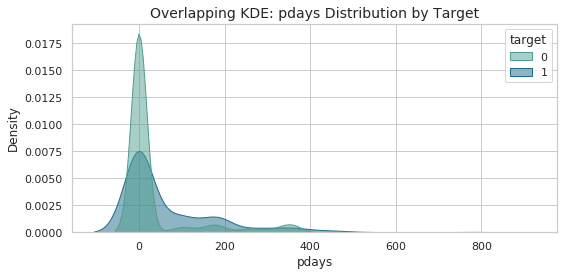

Point-Biserial Correlation: 0.105
P-value: 1.477e-12
Conclusion: The relationship is statistically significant.
----------------------------------------

--- Analyzing: previous ---


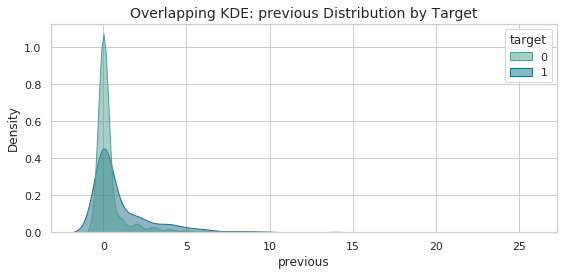

Point-Biserial Correlation: 0.117
P-value: 2.830e-15
Conclusion: The relationship is statistically significant.
----------------------------------------

--- Analyzing: post_campaign_action ---


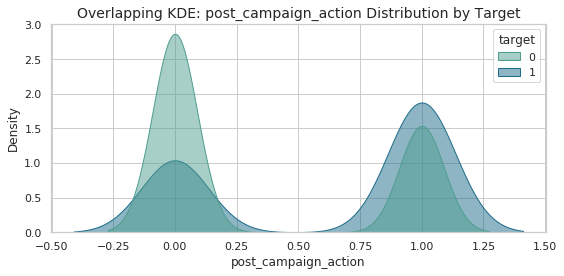

Point-Biserial Correlation: 0.194
P-value: 9.614e-40
Conclusion: The relationship is statistically significant.
----------------------------------------



In [100]:
print("=========================================")
print("NUMERIC FEATURES VS TARGET")
print("=========================================\n")

for col in numeric_cols:
    print(f"--- Analyzing: {col} ---")
    
    # Plotting
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=data, x=col, hue=target_col, fill=True, palette='crest', common_norm=False, alpha=0.5)
    
    plt.title(f"Overlapping KDE: {col} Distribution by Target", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Statistics
    pbc_corr, pbc_pval = stats.pointbiserialr(data[target_col], data[col])
    print(f"Point-Biserial Correlation: {pbc_corr:.3f}")
    print(f"P-value: {pbc_pval:.3e}")
    
    if pbc_pval < 0.05:
        print("Conclusion: The relationship is statistically significant.")
    else:
        print("Conclusion: The relationship is NOT statistically significant.")
    print("-" * 40 + "\n")

# Processing recommendations

## Categorising features in dataset to potentially develop model on (assuming these definitions of the variables)

#### A. Client Demographics 
- age: The client's age.
- job : Type of job 
- marital : Marital status.
- education: Education level.

#### B. Financial Profile 
- default : Do they have credit in default? 
- balance: Average yearly balance in euros/dollars.
- housing : Do they have a housing loan?
- loan : Do they have a personal loan?

#### C. Current Campaign Data 
- contact: Communication type 
- day : Last contact day of the month 
- month : Last contact month of the year 
- campaign : Number of times this client was contacted during this campaign.

#### D. Historical Campaign Data 
- pdays : Number of days since the client was last contacted from a previous campaign.
- previous : Number of times this client was contacted before this campaign.
- poutcome: Outcome of the previous marketing campaign 

### Data cleaning/processing recommendations

### 1. Impute missing values in columns that contain them (small amounts, seems to be missing completely at random, so imputation with median/mode is suitable)
###### small percentage missing in :
- education  ->  Fill with mode (most common category)
- balance    ->  Fill missing 'balance' with the median 
- contact    ->  Fill with 'Unknown' category
- job        ->  Fill with mode (most common category)

In [ ]:
# Impute missing values
# 1. Numeric: Fill missing 'balance' with the median
data['balance'] = data['balance'].fillna(data['balance'].median())

# 2. Categorical: Fill 'education' and 'job' with the mode (most common value)
data['education'] = data['education'].fillna(data['education'].mode()[0])
data['job'] = data['job'].fillna(data['job'].mode()[0])

# 3. Categorical (Logical): Fill 'contact' with 'Unknown'
data['contact'] = data['contact'].fillna('Unknown')

# Verify that all missing values have been handled
print(data[['education', 'balance', 'contact', 'job']].isnull().sum())

### 2. Cap max age 

##### The age column seems to contain a max value of 131, which seems to be an outlier/data entry error
- Instead of calculating a max upper boundary using Tukey's IQR method, simply use good judgement for age and cap the age column at a max of a 100, ie any age greater than a 100 is replaced by a value of a 100 instead

In [ ]:
# Keep only rows where age is logically sound
data = data[data['age'] <= 100]

### 3. Convert target to binary

In [ ]:
#convert target to numeric binary
data['target'] = data['target'].map({'yes': 1, 'no': 0})

### 4. Convert categorical features with only 2 categories (yes/no) to numeric binary type

In [ ]:
data['default'] = data['default'].map({'yes': 1, 'no': 0})
data['housing'] = data['housing'].map({'yes': 1, 'no': 0})
data['loan'] = data['loan'].map({'yes': 1, 'no': 0})

### 5. Drop zero variance features

- The column default consist of 2 unique values, with 98,3% of the values being 'no. This indicates that it will contain little to no predictive power and potentially just add noise

In [ ]:
data = data.drop(columns=['default'])

### 6.  Distribution of pdays and previous columns very skewed, investigate

- 81% of values are -1, which is not a valid number of days. Most likely to be a special code/placeholder to represent customer who have never been contacted for a campaign previously
- Potential to engineer new feature -> Previously contacted vs never previously contacted
- previous column- 81% of values contain 0, but assuming it means number of times contacted previously can leave variable as is, no special codes etc

In [105]:
data['pdays'].value_counts(normalize=True).sort_index()

-1      0.818501
 1      0.000438
 2      0.001754
 3      0.000219
 5      0.000219
          ...   
 687    0.000219
 761    0.000219
 804    0.000219
 808    0.000219
 871    0.000219
Name: pdays, Length: 292, dtype: float64

In [106]:
data['previously_contacted'] = np.where(data['pdays'] == -1, 0, 1)
#Potentially apply other transformation to pdays?Or better tansformation?

### 7. Potential data leakage variables -> Drop from modelling base

- post_campaign_action  -> anything that happens post-campaign could be influenced by the outcome/target, ie data leakage
- Duration              -> assuming this is the time duration of the phone call, this info will not be available for the model when predicting who to call in the future

In [107]:
data = data.drop(columns=['post_campaign_action','duration'])

### 8. For categorical variables that have high number of categories, group some smaller categories (less than 5% distribution) together. Then create some new features (ie beginning_of_month, mid_month, end_month) and hot encode

### 9. Need to encode/transform month and day variables

# Next note book will apply all the cleaning/processing/feature engineering to the data